# Exercício Prático 2: Sistema Especialista

Disciplina: Inteligência Artificial


Período: 2026.1

Nomes: Pedro Henrique de Oliveira Duarte, Rodrigo Girão Motta

Matrículas: XXXXXXXXXXX, XXXXXXXXXXX

Problema: predizer se um veículo é aceitável ou não.

Link do dataset: (Foi utilizado o dataset Car Evaluation disponível na UCI Machine Learning Repository e acessado através do OpenML/scikit-learn) https://archive.ics.uci.edu/dataset/19/car+evaluation

Resumo: O dataset Car Evaluation é utilizado para classificar veículos com base nas suas características, como custo, capacidade e segurança. Assim, consegue determinar se um carro é inaceitável, aceitável, bom ou muito bom a partir de características categóricas.

### 0. Instalação de dependências

- Biblioteca **numpy**: matemática e álgebra linear com vetores e matrizes
- Biblioteca **pandas**: análise e manipulação de dados tabulares
- Biblioteca **scikit-learn**: caixa de ferramentas para aprendizado de máquina
- Biblioteca **matplotlib**: visualização de dados

In [1]:
%pip install numpy pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Coleta de dados

In [2]:
import pandas as pd

from sklearn.datasets import fetch_openml

car = fetch_openml("car", version=3, as_frame=True)

In [3]:
print(car.DESCR[:1000])
print(car.frame.head())

**Author**: Marko Bohanec, Blaz Zupan  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/car+evaluation) - 1997   
**Please cite**: [UCI](http://archive.ics.uci.edu/ml/citation_policy.html)  

**Car Evaluation Database**  
This database was derived from a simple hierarchical decision model originally developed for the demonstration of DEX (M. Bohanec, V. Rajkovic: Expert system for decision making. Sistemica 1(1), pp. 145-157, 1990.).

The model evaluates cars according to the following concept structure:
 
    CAR                      car acceptability
    . PRICE                  overall price
    . . buying               buying price
    . . maint                price of the maintenance
    . TECH                   technical characteristics
    . . COMFORT              comfort
    . . . doors              number of doors
    . . . persons            capacity in terms of persons to carry
    . . . lug_boot           the size of luggage boot
    . . safety               estim

In [4]:
# já vem como DataFrame e com Target
df = car.frame

# Imprime as dimensões da tabela
print("Dataset shape:", df.shape)

# Mostra as primeiras linhas
df.head()

Dataset shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
# Visualiza a tabela
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [6]:
# Visualiza as estatísticas das características
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,high,high,2,2,big,high,unacc
freq,432,432,432,576,576,576,1210


### 2. Pré-processamento

Dados já estão "limpos" e em formato amigável, não é necessário muito pré-processamento

In [7]:
# Separa o dataset em X e y (X e f(X))
y = df["class"]
X = df.drop("class", axis=1)

### 3. Seleção de modelo

Decidimos separar o dataset em 80% para treino e 20% para teste (holdout aleatório)

In [8]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print("Dataset splits:")
print()
print("X for train:", X_train.shape)
print("y for train:", y_train.shape)
print()
print("X for test:", X_test.shape)
print("y for test:", y_test.shape)

Dataset splits:

X for train: (1382, 6)
y for train: (1382,)

X for test: (346, 6)
y for test: (346,)


Poderíamos usar vários algoritmos diferentes (e, consequentemente, classes de funções h diferentes) e compará-los entre si

Para este exemplo, vamos usar apenas a regressão linear

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

test_preds = model.predict(X_test)

acc = accuracy_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds, average="weighted")

print(f"Test Accuracy={acc:.3f}")
print(f"F1 Score={f1:.3f}")

Test Accuracy=0.743
F1 Score=0.691


In [12]:
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [13]:
y_pred = model.predict(X_test)

In [14]:
y_pred

array(['unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'acc',
       'acc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc'

### 4. Avaliação

### 5. Matriz de Confusão

[[ 29   0  54   0]
 [  5   0   6   0]
 [  7   0 228   0]
 [ 17   0   0   0]]


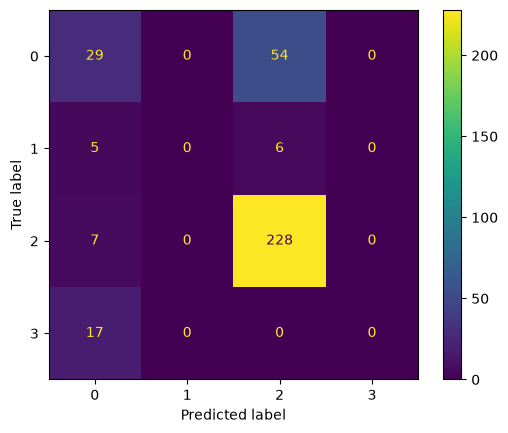

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(cm).plot()

### 6. Imprimir a árvore de decisão

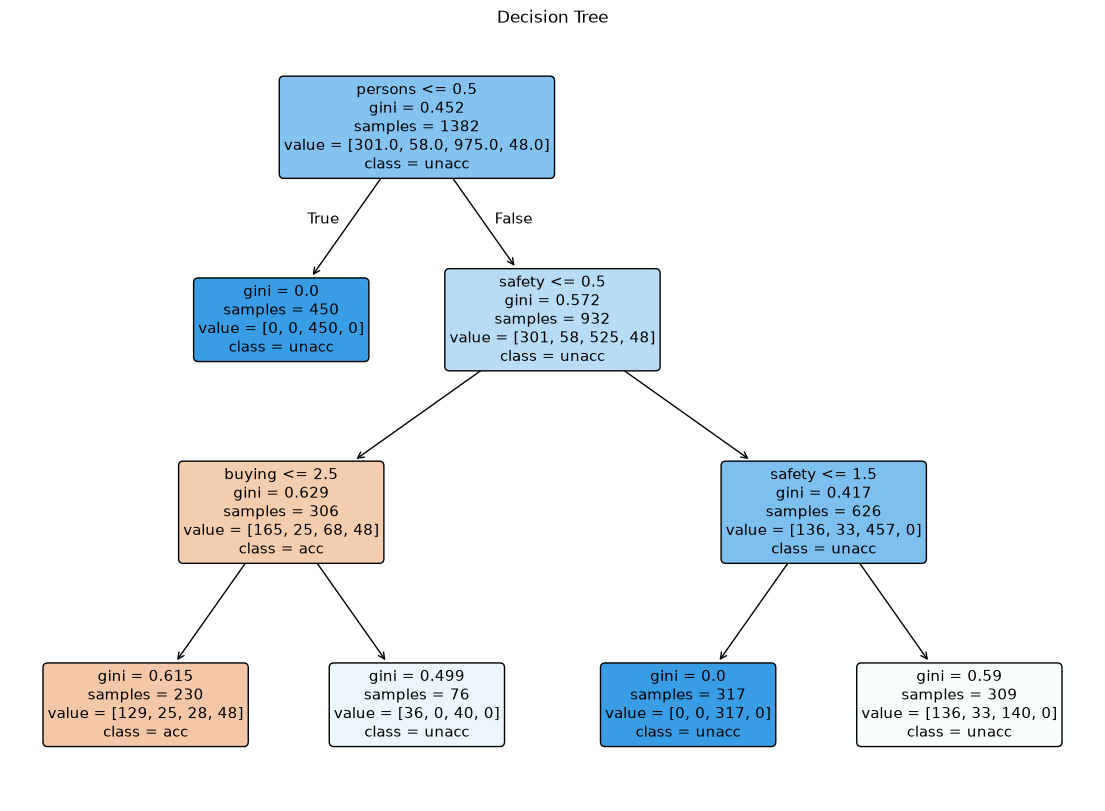

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()